# 회전행렬 R 직접 추정 — target 1 rep 캘리 + source 집계 (MPS판)
> ⚡ Apple Silicon **MPS** 가속판. 로직은 CUDA판과 동일. (notebook/mps/ 에 위치)


samsung1(source) → samsung2(target) IMU 축차를, **gravity alignment 베스트 세션(latpulldown)** 으로 직접 푼다.

**설계 원칙(근거 기반):**
- 캘리브레이션 제약은 **target 쪽**에만 있다 → **target = 1 rep**(beep 분절). source(samsung1)는 이미 가진 도메인이라 1 rep 으로 제한할 이유가 없다 → **source = 집계 표현(분포/레퍼런스)**.
- 정지 스냅샷(중력 1벡터)은 tilt(2DOF)만 → yaw 미결정이라 이전엔 탐색(70.5%). 1 rep 시계열엔 중력+모션이 모두 있어 **full R 을 탐색 없이 직접** 구한다.
- source 범위: `full`(전체 도메인 sub1~14 집계). (단일피험자 sub2 비교는 제거)
- R 추정 2종: **B.Kabsch(단일 rep, gravity 제거)** · **C.PCA프레임(집계)** — B는 source도 1 rep, C는 source 집계
- 기준선: raw / 수동 YXZ / yaw-sweep 70.5%
- ⚠️ source·target 은 **다른 사람**(sub2/sub7) → 경로 차이가 R 잔차로 섞인다(원리적 한계). 그래서 source 를 집계로 안정화하는 게 핵심.

## 0. 셋업 — 회전 유틸

In [40]:
import os, sys, importlib, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib  # 한글 폰트

ROOT = os.path.abspath('../..')
sys.path.insert(0, ROOT)
import eval_utils as U
importlib.reload(U)

IMU = U.IMU_COLS  # ['triceps_X','triceps_Y','triceps_Z']
N = 200           # 리샘플 길이

# 기준 세션 (gravity alignment 베스트: latpulldown)
LP_SRC_FILE = 'sub2_latpulldown_plot_and_store_rep_2.143.csv'                # samsung1 / sub2 (viz용 1사이클)
LP_TGT_FILE = 'Data_NINA11_2025.09.16_10.42.27_sub7_latpulldown_1_59_6.csv'  # samsung2 / sub7 (캘리 1 rep)

def unit(v):
    v = np.asarray(v, float); return v / (np.linalg.norm(v) + 1e-12)
def unit_rows(M):
    M = np.asarray(M, float); return M / (np.linalg.norm(M, axis=1, keepdims=True) + 1e-12)
def angle_deg(a, b):
    return float(np.degrees(np.arccos(np.clip(np.dot(unit(a), unit(b)), -1, 1))))
def kabsch(src, tgt):
    # src_i ~= R @ tgt_i 인 proper rotation R (det=+1). 행벡터: src ~= tgt @ R.T
    H = np.asarray(tgt).T @ np.asarray(src)
    U_, _, Vt = np.linalg.svd(H); V = Vt.T
    d = np.sign(np.linalg.det(V @ U_.T))
    return V @ np.diag([1,1,d]) @ U_.T

print('helpers ready | 기준:', LP_SRC_FILE, '<->', LP_TGT_FILE)

helpers ready | 기준: sub2_latpulldown_plot_and_store_rep_2.143.csv <-> Data_NINA11_2025.09.16_10.42.27_sub7_latpulldown_1_59_6.csv


## 1. 모델 / 데이터 로드

In [41]:
import torch
DEV = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model   = U.load_mm_model(os.path.join(ROOT, 'weights', 'mm_no_da_seed42_best_model.pth'), device=DEV)
S1      = pd.read_parquet(os.path.join(ROOT, 'data', 'samsung1.parquet'),
                          columns=IMU + ['filename','timestamp','exercise','subject','absolute_time'])
dtw_ref = U.build_dtw_reference(S1, session_col='filename', time_col='timestamp')
df_tgt  = pd.read_parquet(os.path.join(ROOT, 'data', 'samsung2.parquet'))
print('로드 완료 |', model.__class__.__name__, '| device', DEV, '| S1', S1.shape, '| df_tgt', df_tgt.shape)

로드 완료 | InterFusionClassifier | device mps | S1 (16148132, 8) | df_tgt (26224560, 12)


## 2. 평가 하네스 + 기준선

`acc_dtw(R)` = R(target→source) 적용 후 **정확도(MM 모델 추론)** 와 **DTW(라벨-free 정렬도)** 반환.
EMG 전처리는 `MMEvalCache` 로 1회만(이후 IMU 변환만 반복). > ⚠️ 캐시 빌드 + 추론이라 무겁다(CPU 느림).

In [42]:
# ★ 무거운 셀: EMG 전처리 캐시 1회 빌드
cache = U.MMEvalCache(df_tgt, model=model)
YXZ   = np.array([[0,1,0],[1,0,0],[0,0,1.]])  # 수동 X<->Y swap baseline

def target_raw_segments(df, ref_keys, min_len=20):
    segs = {}
    for ex in ref_keys:
        sub = df[df['exercise'] == ex]
        if not len(sub): continue
        sess = sorted(sub['csv_filename_l'].unique())[0]
        mat = (sub[sub['csv_filename_l'] == sess].sort_values('Index_Time')[IMU].to_numpy(np.float64))
        if len(mat) >= min_len: segs[ex] = mat
    return segs
tgt_raw = target_raw_segments(df_tgt, dtw_ref.keys())

def acc_dtw(R):
    # R(target->source) 의 (정확도%, 평균DTW)
    acc = cache.accuracy(lambda a, R=R: a @ R.T)
    per = [np.mean([U._dtw_mv(s, U._resample(U._zscore(tgt_raw[ex] @ R.T), N)) for s in src])
           for ex, src in dtw_ref.items() if ex in tgt_raw and src]
    return acc, float(np.mean(per))

RESULTS = {}
RMATS = {}
raw_acc, raw_dtw = acc_dtw(np.eye(3))
yxz_acc, yxz_dtw = acc_dtw(YXZ)
YAW_SWEEP_BEST = 70.51  # 참고: 단일중력 tilt + yaw 30deg x12 탐색(latpulldown) 베스트
RESULTS['raw (identity)'] = (raw_acc, raw_dtw)
RESULTS['수동 YXZ']        = (yxz_acc, yxz_dtw)
print(f'캐시 윈도우 {cache.n_windows}')
print(f'[baseline] raw      acc={raw_acc:5.2f}%  dtw={raw_dtw:.1f}')
print(f'[baseline] 수동 YXZ  acc={yxz_acc:5.2f}%  dtw={yxz_dtw:.1f}')
print(f'[참고]     yaw-sweep acc={YAW_SWEEP_BEST:.2f}%   <- 직접-R 목표선')

캐시 윈도우 21629
[baseline] raw      acc=20.48%  dtw=364.5
[baseline] 수동 YXZ  acc=59.03%  dtw=355.2
[참고]     yaw-sweep acc=70.51%   <- 직접-R 목표선


## 3. 캘리 데이터 — 무엇을 골랐나 (증거)

**target = beep 으로 자른 1 rep**, **source = 집계**(분포/레퍼런스). 먼저 무엇을 골랐는지 시각화로 확인한다.

In [43]:
def session_imu(df, sess_col, sess, time_col):
    s = df[df[sess_col] == sess].sort_values(time_col)
    t = s[time_col].to_numpy(float); t = t - t[0]
    return t, s[IMU].to_numpy(np.float64)

# TARGET: 전체 세션 + beep onset 으로 1 rep
t_tgt, A_tgt = session_imu(df_tgt, 'csv_filename_l', LP_TGT_FILE, 'Index_Time')
beep_tgt = (df_tgt[df_tgt['csv_filename_l'] == LP_TGT_FILE].sort_values('Index_Time')['beep'].to_numpy())
onsets_idx = np.where((beep_tgt[1:] != 0) & (beep_tgt[:-1] == 0))[0] + 1
BEEP_I = 1                                  # onsets[i]~onsets[i+1] = 1 rep
i0, i1 = onsets_idx[BEEP_I], onsets_idx[BEEP_I + 1]
rep_tgt = A_tgt[i0:i1]                       # ★ 캘리에 쓰는 유일한 target 데이터(1 rep)

# SOURCE: 클립 전체 + 클립 '중앙'의 자기상관 1사이클 — ★ B.Kabsch 의 source 1 rep 입력
t_src, A_src = session_imu(S1, 'filename', LP_SRC_FILE, 'timestamp')
fs_src = 1.0 / np.median(np.diff(t_src))
def dominant_period(X, fs, pmin=0.6, pmax=8.0):
    x = X.mean(1); x = x - x.mean()
    ac = np.correlate(x, x, 'full')[len(x)-1:]
    lo, hi = int(pmin*fs), min(int(pmax*fs), len(ac)-1)
    return lo + int(np.argmax(ac[lo:hi]))
P = dominant_period(A_src, fs_src)
s0 = int(np.clip((len(A_src) - P) // 2, 0, len(A_src) - P - 1))   # 클립 시간축 '중앙'에서 1사이클
src_cyc = A_src[s0:s0 + P]                   # ★ source 1 rep (클립 중앙)

zs = lambda M: U._resample(U._zscore(M), N)
print(f'TARGET 1 rep: beep{BEEP_I}~{BEEP_I+1}  t=[{t_tgt[i0]:.2f},{t_tgt[i1]:.2f}]s  ({len(rep_tgt)} samples)')
print(f'SOURCE 1 rep: 클립중앙 t=[{t_src[s0]:.2f},{t_src[s0+P]:.2f}]s  ({len(src_cyc)} samples, fs≈{fs_src:.0f}Hz)')

TARGET 1 rep: beep1~2  t=[14.63,19.19]s  (9112 samples)
SOURCE 1 rep: 클립중앙 t=[6.45,8.54]s  (4029 samples, fs≈1926Hz)


### 3-1. 선택 시각화 — 이게 한 rep 이다

Text(0.5, 0, 't [s]')

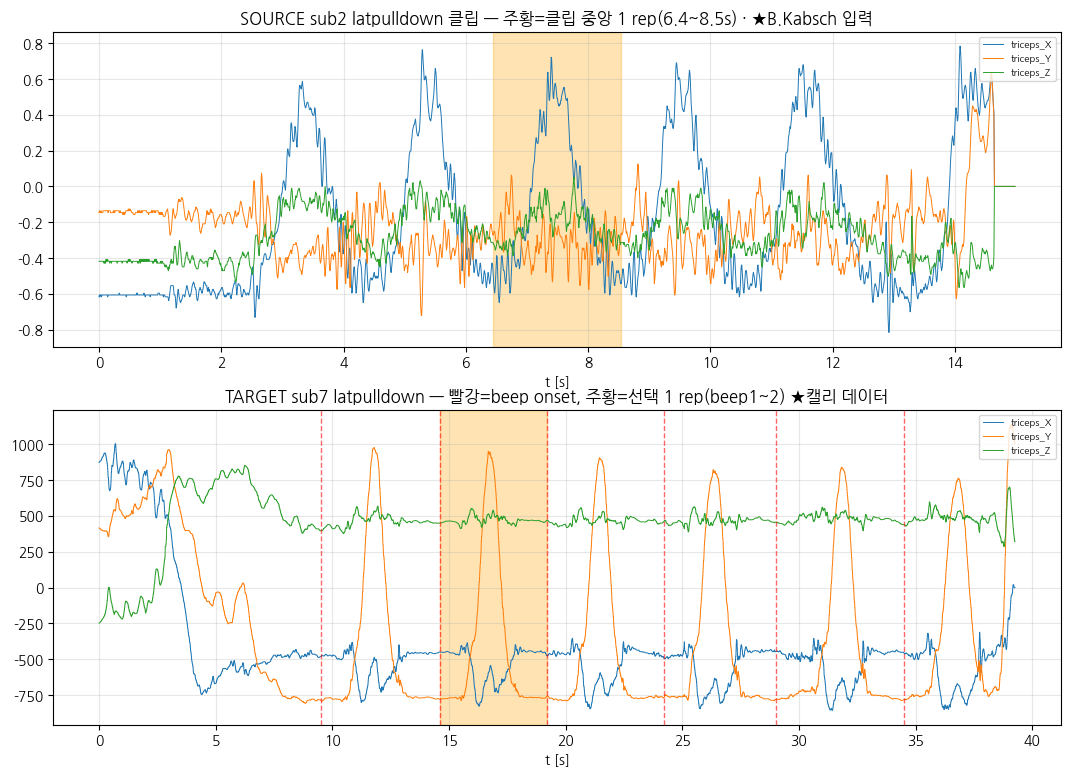

In [51]:
fig, ax = plt.subplots(2, 1, figsize=(13, 9))
# (1) source 클립 전체 + 클립 중앙 1 rep 강조
for k, c in enumerate(IMU): ax[0].plot(t_src, A_src[:, k], lw=.7, label=c)
ax[0].axvspan(t_src[s0], t_src[s0+P], color='orange', alpha=.3)
ax[0].set_title(f'SOURCE sub2 latpulldown 클립 — 주황=클립 중앙 1 rep({t_src[s0]:.1f}~{t_src[s0+P]:.1f}s) · ★B.Kabsch 입력')
ax[0].legend(fontsize=7, loc='upper right'); ax[0].grid(alpha=.3); ax[0].set_xlabel('t [s]')
# (2) target 세션 전체 + beep + 선택 rep 강조
for k, c in enumerate(IMU): ax[1].plot(t_tgt, A_tgt[:, k], lw=.7, label=c)
for o in onsets_idx: ax[1].axvline(t_tgt[o], color='red', ls='--', lw=1, alpha=.6)
ax[1].axvspan(t_tgt[i0], t_tgt[i1], color='orange', alpha=.3)
ax[1].set_title(f'TARGET sub7 latpulldown — 빨강=beep onset, 주황=선택 1 rep(beep{BEEP_I}~{BEEP_I+1}) ★캘리 데이터')
ax[1].legend(fontsize=7, loc='upper right'); ax[1].grid(alpha=.3); ax[1].set_xlabel('t [s]')
# (3) 정규화 오버레이 — source 1 rep(solid) vs target 1 rep(dashed): B.Kabsch 가 맞추는 두 신호

## 4. source 집계 표현 만들기 (full)

`target = rep_tgt`(1 rep) 고정. source 는 latpulldown 을 **집계**해서:
- `points` : 분포 방법(B 중력·모션축, C PCA)용 raw IMU 점구름
- `segs`   : 부호/후보 모호성을 가르는 **rep-DTW 레퍼런스**(세션 단위, 여러 개)

scope `full`=전체 도메인(피험자별 1세션) 집계.

In [45]:
def build_src(scope, max_seg=6, cap=150000):
    sub = S1[S1.exercise == 'latpulldown']
    if scope == 'sub2':
        sub = sub[sub.subject == 'sub2']
        files = sorted(sub.filename.unique())[:max_seg]
    else:  # full: 도메인 대표로 피험자별 첫 세션
        files = []
        for subj in sorted(sub.subject.unique()):
            ff = sorted(sub[sub.subject == subj].filename.unique())
            if ff: files.append(ff[0])
        files = files[:max_seg]
    pts = sub[IMU].to_numpy(np.float64)
    step = max(1, len(pts)//cap); pts = pts[::step]
    segs = []
    for f in files:
        m = sub[sub.filename == f].sort_values('timestamp')[IMU].to_numpy(np.float64)
        if len(m) >= 20: segs.append(U._resample(m, N))
    return dict(points=pts, files=files,
                segs_z=[U._zscore(s) for s in segs])

SRC = {sc: build_src(sc) for sc in ['full']}
for sc, d in SRC.items():
    print(f"[{sc:4s}] points={len(d['points']):6d}  segs={len(d['segs_z'])}  files={[f[:18] for f in d['files']][:3]}...")

def planarity(M):
    sv = np.linalg.svd(M - M.mean(0), compute_uv=False); return sv / sv[0]
print('target rep planarity s2/s0 =', round(planarity(rep_tgt)[2], 3), '(작을수록 평면적=yaw 약함)')

[full] points=163540  segs=6  files=['sub1_latpulldown_p', 'sub10_latpulldown_', 'sub11_latpulldown_']...
target rep planarity s2/s0 = 0.041 (작을수록 평면적=yaw 약함)


## 5. R 추정 방법 정의 (B, C)

- **B. Kabsch(단일 rep)**: gravity 정렬 **없이** source 1 rep(`src_cyc`, 클립 중앙)과 target 1 rep(`rep_tgt`)을
  N 리샘플 · **평균중심(중력 DC 제거)** 후 **index 대응**으로 직접 Kabsch → R(target→source). 부호 모호성 없음.
- **C. PCA 프레임**: source **집계** 점구름과 `rep_tgt` 의 PCA 주축 프레임 정렬. 부호/후보는
  **source 집계 세그먼트에 대한 rep-DTW**(라벨-free)로 택1 → 평가지표와 일치.

In [46]:
def pca_frame(M):
    return np.linalg.svd(M - M.mean(0), full_matrices=False)[2]   # rows=주축(내림차순)

def rep_dtw_segs(R, scope):
    # 회전된 target rep 과 source 집계 세그먼트들의 평균 DTW (싸다; C 부호 선택용)
    zt = zs(rep_tgt @ R.T)
    return float(np.mean([U._dtw_mv(sz, zt) for sz in SRC[scope]['segs_z']]))

def m_kabsch_rep(scope):
    # gravity alignment 없이 source 1 rep ↔ target 1 rep 직접 Kabsch.
    # 두 rep 을 N 리샘플 + 평균중심(중력 DC 제거) 후 index 대응으로 정렬 → R(target→source).
    src = U._resample(src_cyc, N); src = src - src.mean(0)
    tgt = U._resample(rep_tgt, N); tgt = tgt - tgt.mean(0)
    return kabsch(src, tgt)                                # src ~= tgt @ R.T

def m_pca(scope):
    Fs, Ft = pca_frame(SRC[scope]['points']), pca_frame(rep_tgt)
    best = None
    for sg in itertools.product((1,-1), repeat=3):
        R = Fs.T @ np.diag(sg) @ Ft
        if np.linalg.det(R) < 0: continue
        sc = rep_dtw_segs(R, scope)
        best = (sc, R) if best is None or sc < best[0] else best
    return best[1]

METHODS = {'B. Kabsch(단일 rep)': m_kabsch_rep, 'C. PCA 프레임': m_pca}
print('methods ready:', list(METHODS))

methods ready: ['B. Kabsch(단일 rep)', 'C. PCA 프레임']


## 6. 실행 — B(단일 rep) · C(full 집계) (정확도 + 회전행렬 R 출력)

In [47]:
# B.Kabsch 는 단일 rep(scope 무관), C.PCA 는 source 집계(scope='full') → 키 표기 다르게
SCOPE = 'full'
for name, fn in METHODS.items():
    R = fn(SCOPE)
    a, d = acc_dtw(R)
    key = f'{name} [{SCOPE}]' if 'PCA' in name else name      # 집계 쓰는 C 만 scope 태그
    RESULTS[key] = (a, d); RMATS[key] = R
    print(f'{key:26s}  acc={a:5.2f}%  dtw={d:.1f}   R(target→source, imu @ R.T):')
    print(np.round(R, 4))

B. Kabsch(단일 rep)           acc=61.88%  dtw=350.0   R(target→source, imu @ R.T):
[[-0.0529  0.9983 -0.0233]
 [-0.0477 -0.0258 -0.9985]
 [-0.9975 -0.0517  0.049 ]]
C. PCA 프레임 [full]           acc=75.82%  dtw=297.2   R(target→source, imu @ R.T):
[[ 0.0781  0.9956  0.0514]
 [ 0.8623 -0.0416 -0.5046]
 [-0.5003  0.0837 -0.8618]]


## 6.5 다른 축 정렬 방법 합치기 — gravity / permutation

같은 평가 하네스(`acc_dtw`)로 **gravity alignment**(정지중력 tilt + yaw best-by-DTW)와
**permutation 48조합 best**(`results/imu_permutation_bruteforce.csv`)를 평가해 `RESULTS`/`RMATS` 에 추가한다.
→ 다음 종합 차트에서 직접 R(B·C)·baseline 과 한 화면에서 비교하고, 각 R 행렬도 함께 출력한다.

In [48]:
# ── 다른 축정렬 방법(gravity / permutation)을 같은 하네스로 평가해 합치기 ──
def rot_axis(axis, deg):                              # 중력축 둘레 yaw 회전(Rodrigues)
    a = unit(axis); th = np.radians(deg)
    K = np.array([[0,-a[2],a[1]],[a[2],0,-a[0]],[-a[1],a[0],0]])
    return np.eye(3) + np.sin(th)*K + (1-np.cos(th))*(K@K)

def static_vec(df, sess_col, file, time_col, center_time, half=0.1):   # 정지시각 ±0.1s 평균=중력
    s = df[df[sess_col] == file].copy()
    s[time_col] = pd.to_datetime(s[time_col]); s = s.sort_values(time_col)
    c = str(center_time).strip()
    center = pd.to_datetime(f'{s[time_col].iloc[0].date()} {c}') if len(c) <= 12 else pd.to_datetime(c)
    w = s[(s[time_col] >= center - pd.Timedelta(seconds=half)) &
          (s[time_col] <= center + pd.Timedelta(seconds=half))]
    return unit(w[IMU].to_numpy(float).mean(0))

def dtw_only(R):                                      # 모델 추론 없이 DTW 만(yaw 라벨-free 선택용)
    per = [np.mean([U._dtw_mv(s, U._resample(U._zscore(tgt_raw[ex] @ R.T), N)) for s in src])
           for ex, src in dtw_ref.items() if ex in tgt_raw and src]
    return float(np.mean(per))

# (1) gravity alignment — latpulldown 정지중력(±0.1s) tilt + yaw 10°×36 best-by-DTW
g1 = static_vec(S1,     'filename',       LP_SRC_FILE, 'absolute_time', '16:24:25')   # source
g2 = static_vec(df_tgt, 'csv_filename_l', LP_TGT_FILE, 'TimeStamp',     '10:42:41')   # target
R_tilt = U.rotation_align(g2, g1)
R_grav = min((rot_axis(g1, th) @ R_tilt for th in range(0, 360, 10)), key=dtw_only)
ag, dg = acc_dtw(R_grav)
RESULTS['gravity yaw-sweep'] = (ag, dg); RMATS['gravity yaw-sweep'] = R_grav

# (2) permutation 48조합 best(CSV) — 순열·부호를 회전(순열)행렬로 재구성
perm = pd.read_csv(os.path.join(ROOT, 'results', 'imu_permutation_bruteforce.csv'))
pb   = perm.sort_values('acc', ascending=False).iloc[0]
AXMAP = {'X':0, 'Y':1, 'Z':2}
R_perm = np.zeros((3, 3))
for k, (j, s) in enumerate(zip([AXMAP[ch] for ch in pb['order']],
                               [1 if ss == '+' else -1 for ss in str(pb['signs'])])):
    R_perm[k, j] = s
ap, dp = acc_dtw(R_perm)
RESULTS[f'permutation best ({pb["name"]})'] = (ap, dp)
RMATS[f'permutation best ({pb["name"]})'] = R_perm

# baseline 도 R 기록(아래 종합 출력용)
RMATS['raw (identity)'] = np.eye(3); RMATS['수동 YXZ'] = YXZ

print(f'gravity yaw-sweep      : acc={ag:5.2f}%  dtw={dg:.1f}   det={np.linalg.det(R_grav):+.2f}')
print(f'permutation {pb["name"]:9s}: acc={ap:5.2f}%  dtw={dp:.1f}   det={np.linalg.det(R_perm):+.2f}')

gravity yaw-sweep      : acc=69.90%  dtw=302.5   det=+1.00
permutation YXZ_++-  : acc=65.77%  dtw=313.2   det=+1.00


## 7. 종합 비교

,방법,accuracy(%),DTW
0,C. PCA 프레임 [full],75.82,297.2
1,gravity yaw-sweep,69.90,302.5
2,permutation best (YXZ_++-),65.77,313.2
3,B. Kabsch(단일 rep),61.88,350.0
4,수동 YXZ,59.03,355.2
5,raw (identity),20.48,364.5


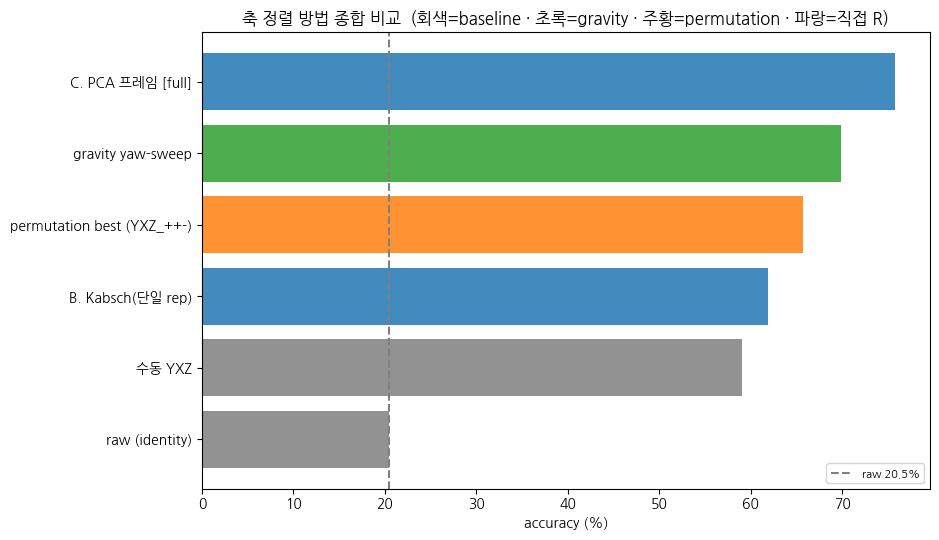

=== 각 방법에 사용된 회전행렬 R (target→source, imu @ R.T) ===

[C. PCA 프레임 [full]]  acc=75.82%  det=+1.000
[[ 0.0781  0.9956  0.0514]
 [ 0.8623 -0.0416 -0.5046]
 [-0.5003  0.0837 -0.8618]]

[gravity yaw-sweep]  acc=69.90%  det=+1.000
[[ 0.3543  0.9253  0.1352]
 [ 0.9349 -0.3471 -0.0742]
 [-0.0217  0.1527 -0.988 ]]

[permutation best (YXZ_++-)]  acc=65.77%  det=+1.000
[[ 0.  1.  0.]
 [ 1.  0.  0.]
 [ 0.  0. -1.]]

[B. Kabsch(단일 rep)]  acc=61.88%  det=+1.000
[[-0.0529  0.9983 -0.0233]
 [-0.0477 -0.0258 -0.9985]
 [-0.9975 -0.0517  0.049 ]]

[수동 YXZ]  acc=59.03%  det=-1.000
[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]

[raw (identity)]  acc=20.48%  det=+1.000
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [49]:
summ = (pd.DataFrame([{'방법': k, 'accuracy(%)': round(v[0],2), 'DTW': round(v[1],1)}
                      for k, v in RESULTS.items()])
        .sort_values('accuracy(%)', ascending=False).reset_index(drop=True))
display(summ)

def bar_color(m):
    if m.startswith('raw') or '수동 YXZ' in m: return 'tab:gray'    # baseline
    if 'gravity' in m:     return 'tab:green'
    if 'permutation' in m: return 'tab:orange'
    return 'tab:blue'                                               # 직접 R (B, C)

fig, ax = plt.subplots(figsize=(9.5, 5.5))
names = list(summ['방법'][::-1])
ax.barh(names, summ['accuracy(%)'][::-1], color=[bar_color(m) for m in names], alpha=.85)
ax.axvline(raw_acc, color='gray', ls='--', label=f'raw {raw_acc:.1f}%')
ax.set_xlabel('accuracy (%)'); ax.legend(fontsize=8)
ax.set_title('축 정렬 방법 종합 비교  (회색=baseline · 초록=gravity · 주황=permutation · 파랑=직접 R)')
plt.tight_layout(); plt.show()

# ── 각 방법에 사용된 회전행렬 R 전체 출력 (정확도 내림차순) ──
print('=== 각 방법에 사용된 회전행렬 R (target→source, imu @ R.T) ===')
for _, row in summ.iterrows():
    name = row['방법']
    if name in RMATS:
        R = RMATS[name]
        print(f'\n[{name}]  acc={row["accuracy(%)"]:.2f}%  det={np.linalg.det(R):+.3f}')
        print(np.round(R, 4))
    else:
        print(f'\n[{name}]  (R 미기록)')

In [ ]:
# ── 결과 R 행렬 저장 (.npy) — data_preprocess_MM.py 가 --R 로 그대로 로드 ──
# 규약: 노트북·전처리 모두 aligned = imu @ R.T (R = target→source). 따라서 "R 그대로" 저장.
R_OUT = os.path.join(ROOT, 'results', 'R_matrices')
os.makedirs(R_OUT, exist_ok=True)

# RMATS 표시키 → preprocess --method 슬러그 (사용자 지정 5종: raw/pca/gravity/permutation/kabsch)
SAVE_MAP = {
    'raw':     'raw (identity)',
    'kabsch':  'B. Kabsch(단일 rep)',
    'pca':     'C. PCA 프레임 [full]',
    'gravity': 'gravity yaw-sweep',
}
_perm = next((k for k in RMATS if k.startswith('permutation')), None)
if _perm:
    SAVE_MAP['permutation'] = _perm

for method, key in SAVE_MAP.items():
    if key not in RMATS:
        print(f'  [skip] {method}: RMATS 에 "{key}" 없음 (먼저 위 셀들 실행)')
        continue
    R = np.asarray(RMATS[key], dtype=np.float64)
    np.save(os.path.join(R_OUT, f'R_{method}.npy'), R)
    print(f'  saved  R_{method}.npy   det={np.linalg.det(R):+.3f}')

print('\n# 전처리 실행 (각 메서드 → preprocessed_MM_<method>/):')
for method in SAVE_MAP:
    print(f'  python data_preprocess_MM.py --method {method} --R results/R_matrices/R_{method}.npy')